In [33]:









from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score



## Standard libraries
import numpy as np

## Imports for plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

## PyTorch
import torch

## Torchvision
import torchvision
from torchvision.datasets import SVHN, MNIST, USPS
import torchvision.transforms as T
from torch.utils.data import DataLoader

## Sklearn
from sklearn.manifold import TSNE

## UMAP
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

if IN_COLAB:
  print("Using Google Colab")
  !pip install umap-learn
  from umap import UMAP
  # !pip install adapt
  # !pip install Tensorflow==2.15
else:
  from umap import UMAP

# Path to the folder where the datasets are/should be downloaded
DATASET_PATH = "./data"

Using Google Colab


In [34]:
print("Using torch", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print ("MPS (MacBook) device found.")
    #print('Number of MPS cards: ', torch.mps.device_count())
    #print('Total MPS memory {0:.2f} GB'.format(torch.mps.recommended_max_memory()/pow(10,9)))
elif torch.backends.cuda.is_built():
    device = torch.device("cuda")
    # Ensure that all operations are deterministic on GPU (if used) for reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print ("CUDA device found.")
    print('Number of GPU cards: ', torch.cuda.device_count(), '\nWhich card GPU?', torch.cuda.get_device_name(0))
    print('Total GPU memory {1:.2f} GB. Free GPU memory {0:.2f} GB'.format(torch.cuda.mem_get_info()[0]/pow(10,9),torch.cuda.mem_get_info()[1]/pow(10,9)))
else:
   device = torch.device("cpu")
   print('No MPS or CUDA has been found. PyTorch will use CPU.')

Using torch 2.5.1+cu121
CUDA device found.
Number of GPU cards:  1 
Which card GPU? Tesla T4
Total GPU memory 15.84 GB. Free GPU memory 15.68 GB


In this practical session you will implement and test the method presented in [1] for Unsupervised Domain Adaptation.

You will use three imaging datasets showing 0-9 digits: MNIST, SVHN and USPS.

We know that the output spaces are equal (same labels/classes), namely the digits from 0 to 9, and we will resize the data so that the input spaces are also equal (same number of pixels per image).

In this TP, you will assume a covariate shift and therefore that there is a shift between the marginal disitributions $p_S(X)$ and $p_T(X)$ and that the conditionl distributions $p_S(Y|X)$ and $p_t(Y|X)$ are equal.

As for the other TP, answer all questions and fill the code where you see **XXXXXXXXX**

**Deadline**: please verify on the Moodle/Ecampus the deadline



[1] B. Fernando et al. “Unsupervised Visual Domain Adaptation Using Subspace Alignment”. In: ICCV. 2013.

### **MNIST**

 Let's start by downloading the **MNIST** dataset: a very common and large database of grayscale images showing handwritten digits ranging from 0 to 9. It comprises 60,000 training images and 10,000 testing images of size 28x28.

To cope with the assumption about the "same number of input pixels per image", we choose the input dimension of 32x32 for all datasets. We thus resize all images (originally 28x28) using the padding function "Pad" (add 0 to the borders).


In [8]:
# Transform to normalized Tensors in the range [0,1]
MNIST_train_dataset = MNIST(root=DATASET_PATH, train= True, download=True, transform=T.Compose([T.Pad(2), T.ToTensor()]))
MNIST_test_dataset = MNIST(root=DATASET_PATH, train= False, download=True, transform=T.Compose([T.Pad(2), T.ToTensor()]))

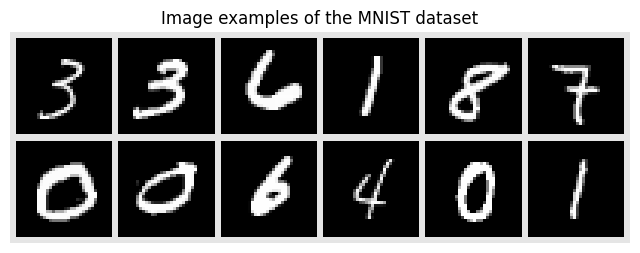

In [9]:
# Visualize some examples
NUM_IMAGES = 12
MNIST_images = torch.stack([MNIST_train_dataset[np.random.randint(len(MNIST_train_dataset))][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(MNIST_images, nrow=6, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8,8))
plt.title("Image examples of the MNIST dataset")
plt.imshow(img_grid)
plt.axis('off')
plt.show()
plt.close()

Be careful ! Even if you put a transform when downloading the data and creating teh Pytorch Dataset, this is actually not applied until you load the data with a DataLoader.

For instance, when you load images in the range $[0,255]$ and you put the transform `ToTensor()`, this should automatically normalize the images in the range $[0,1]$ and transform them into Pytorch tensors. However, if you simply take the data from the DataSet *WITHOUT* the DataLoader...

In [10]:
#This does not apply the normalization to [0-1] (transform To.Tensor() )
MNIST_Xtrain_255 = MNIST_train_dataset.data.numpy()
MNIST_ytrain_255 = MNIST_train_dataset.targets.numpy()


In [11]:
print(MNIST_Xtrain_255.shape)
print(MNIST_ytrain_255.shape)

print('Min Pixel Value: {} \nMax Pixel Value: {}'.format(MNIST_Xtrain_255.min(), MNIST_Xtrain_255.max()))
print('Mean Pixel Value {} \nPixel Values Std: {}'.format(MNIST_Xtrain_255.mean(), MNIST_Xtrain_255.std()))
print('Min Pixel Value: {} \nMax Pixel Value: {}'.format(MNIST_Xtrain_255.min(), MNIST_Xtrain_255.max()))

(60000, 28, 28)
(60000,)
Min Pixel Value: 0 
Max Pixel Value: 255
Mean Pixel Value 33.318421449829934 
Pixel Values Std: 78.56748998339798
Min Pixel Value: 0 
Max Pixel Value: 255


Instead, if we load them with the Dataloader...

In [12]:
MNIST_train_loader = DataLoader(MNIST_train_dataset, batch_size=len(MNIST_train_dataset))
MNIST_test_loader = DataLoader(MNIST_test_dataset, batch_size=len(MNIST_test_dataset))

MNIST_Xtrain_ima = np.squeeze(next(iter(MNIST_train_loader))[0].numpy())
MNIST_ytrain = next(iter(MNIST_train_loader))[1].numpy()

MNIST_Xtest_ima = np.squeeze(next(iter(MNIST_test_loader))[0].numpy())
MNIST_ytest = next(iter(MNIST_test_loader))[1].numpy()


In [13]:
print(MNIST_Xtrain_ima.shape)
print(MNIST_ytrain.shape)

print(MNIST_Xtest_ima.shape)
print(MNIST_ytest.shape)

print('Min Pixel Value: {} \nMax Pixel Value: {}'.format(MNIST_Xtrain_ima.min(), MNIST_Xtrain_ima.max()))
print('Mean Pixel Value {} \nPixel Values Std: {}'.format(MNIST_Xtrain_ima.mean(), MNIST_Xtrain_ima.std()))

print('Min Pixel Value: {} \nMax Pixel Value: {}'.format(MNIST_Xtest_ima.min(), MNIST_Xtest_ima.max()))
print('Mean Pixel Value {} \nPixel Values Std: {}'.format(MNIST_Xtest_ima.mean(), MNIST_Xtest_ima.std()))

(60000, 32, 32)
(60000,)
(10000, 32, 32)
(10000,)
Min Pixel Value: 0.0 
Max Pixel Value: 1.0
Mean Pixel Value 0.10003671795129776 
Pixel Values Std: 0.2752174437046051
Min Pixel Value: 0.0 
Max Pixel Value: 1.0
Mean Pixel Value 0.10145653039216995 
Pixel Values Std: 0.2774091958999634


(12, 32, 32)


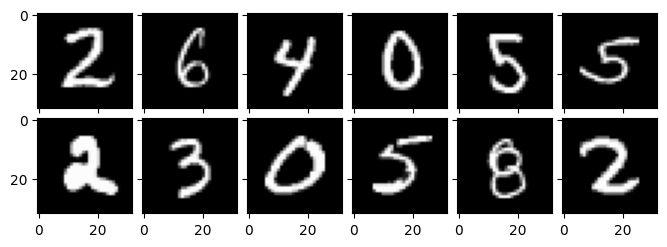

In [14]:
from mpl_toolkits.axes_grid1 import ImageGrid

NUM_IMAGES=12
MNIST_grid = MNIST_Xtrain_ima[np.random.randint(0,len(MNIST_Xtrain_ima),12),:,:]
print(MNIST_grid.shape)

fig = plt.figure(figsize=(8,8))
grid = ImageGrid(fig, 111,  # similar to subplot(111)
                 nrows_ncols=(2, 6),  # creates 2x2 grid of axes
                 axes_pad=0.1,  # pad between axes in inch.
                 )

for ax, im in zip(grid, MNIST_grid):
    # Iterating over the grid returns the Axes.
    ax.imshow(im,cmap='gray')

plt.show()

So we have 60k training images and 10K test images of size $[32 x 32]$. Let's load another dataset

### **SVHN dataset**

The Street View House Numbers (SVHN) dataset is a real-world image dataset for house number detection. It is similar to MNIST since it has the same digit classes (0 to 9), but it is significantly harder due to its real-world setting. SVHN is obtained from house numbers in Google Street View images.

It comprises RGB images of size $32x32$

We change them from RGB to grayscale to compare them with the MNIST images.


In [15]:
SVHN_train_dataset = SVHN(root=DATASET_PATH, split='train', download=True, transform=T.Compose([T.Grayscale(), T.ToTensor()]))
SVHN_test_dataset = SVHN(root=DATASET_PATH, split='test', download=True, transform=T.Compose([T.Grayscale(), T.ToTensor()]))

Using downloaded and verified file: ./data/train_32x32.mat
Using downloaded and verified file: ./data/test_32x32.mat


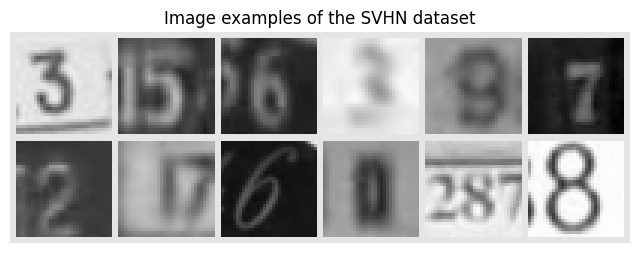

In [16]:
# Visualize some examples
NUM_IMAGES = 12
SVHN_images = torch.stack([SVHN_test_dataset[np.random.randint(len(SVHN_test_dataset))][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(SVHN_images, nrow=6, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8,8))
plt.title("Image examples of the SVHN dataset")
plt.imshow(img_grid)
plt.axis('off')
plt.show()
plt.close()

In [17]:
SVHN_train_loader = DataLoader(SVHN_train_dataset, batch_size=len(SVHN_train_dataset))
SVHN_test_loader = DataLoader(SVHN_test_dataset, batch_size=len(SVHN_test_dataset))

SVHN_Xtrain_ima = np.squeeze(next(iter(SVHN_train_loader))[0].numpy())
SVHN_ytrain = next(iter(SVHN_train_loader))[1].numpy()

SVHN_Xtest_ima = np.squeeze(next(iter(SVHN_test_loader))[0].numpy())
SVHN_ytest = next(iter(SVHN_test_loader))[1].numpy()


In [18]:
print(SVHN_Xtrain_ima.shape)
print(SVHN_ytrain.shape)
print(SVHN_Xtest_ima.shape)
print(SVHN_ytest.shape)

print('Min Pixel Value: {} \nMax Pixel Value: {}'.format(SVHN_Xtrain_ima.min(), SVHN_Xtrain_ima.max()))
print('Mean Pixel Value {} \nPixel Values Std: {}'.format(SVHN_Xtrain_ima.mean(), SVHN_Xtrain_ima.std()))

print('Min Pixel Value: {} \nMax Pixel Value: {}'.format(SVHN_Xtest_ima.min(), SVHN_Xtest_ima.max()))
print('Mean Pixel Value {} \nPixel Values Std: {}'.format(SVHN_Xtest_ima.mean(), SVHN_Xtest_ima.std()))

(73257, 32, 32)
(73257,)
(26032, 32, 32)
(26032,)
Min Pixel Value: 0.0 
Max Pixel Value: 1.0
Mean Pixel Value 0.4452594220638275 
Pixel Values Std: 0.196975976228714
Min Pixel Value: 0.0 
Max Pixel Value: 1.0
Mean Pixel Value 0.45435550808906555 
Pixel Values Std: 0.2220025360584259


Here we have ~73K training images and ~26K test images of the same size $[32 x x32]$

### **USPS**

As last dataset, we will use the USPS dataset which contains images of digits (from 0 to 9) scanned from envelopes by the U.S. Postal Service. It contains a total of 9,298 $16x16$ pixel grayscale images. Images are centered, normalized and show a broad range of font styles.

Even in ths case, we pad them with 0 in order to have $32 x 32$ images.

In [19]:
USPS_train_dataset = USPS(root=DATASET_PATH, train= True, download=True, transform=T.Compose([T.Pad(8), T.ToTensor()]))
USPS_test_dataset = USPS(root=DATASET_PATH, train= False, download=True, transform=T.Compose([T.Pad(8), T.ToTensor()]))

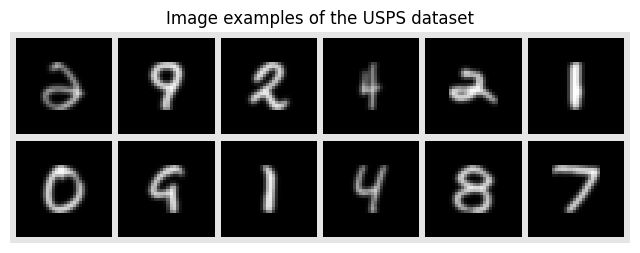

In [35]:
# Visualize some examples
NUM_IMAGES = 12
USPS_images = torch.stack([USPS_train_dataset[np.random.randint(len(USPS_train_dataset))][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(USPS_images, nrow=6, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8,8))
plt.title("Image examples of the USPS dataset")
plt.imshow(img_grid)
plt.axis('off')
plt.show()
plt.close()

In [21]:
USPS_train_loader = DataLoader(USPS_train_dataset, batch_size=len(USPS_train_dataset))
USPS_test_loader = DataLoader(USPS_test_dataset, batch_size=len(USPS_test_dataset))

USPS_Xtrain_ima = np.squeeze(next(iter(USPS_train_loader))[0].numpy())
USPS_ytrain = next(iter(USPS_train_loader))[1].numpy()

USPS_Xtest_ima = np.squeeze(next(iter(USPS_test_loader))[0].numpy())
USPS_ytest = next(iter(USPS_test_loader))[1].numpy()

In [22]:
print(USPS_Xtrain_ima.shape)
print(USPS_ytrain.shape)
print(USPS_Xtest_ima.shape)
print(USPS_ytest.shape)

print('Min Pixel Value: {} \nMax Pixel Value: {}'.format(USPS_Xtrain_ima.min(), USPS_Xtrain_ima.max()))
print('Mean Pixel Value {} \nPixel Values Std: {}'.format(USPS_Xtrain_ima.mean(), USPS_Xtrain_ima.std()))

print('Min Pixel Value: {} \nMax Pixel Value: {}'.format(USPS_Xtest_ima.min(), USPS_Xtest_ima.max()))
print('Mean Pixel Value {} \nPixel Values Std: {}'.format(USPS_Xtest_ima.mean(), USPS_Xtest_ima.std()))

(7291, 32, 32)
(7291,)
(2007, 32, 32)
(2007,)
Min Pixel Value: 0.0 
Max Pixel Value: 0.9960784316062927
Mean Pixel Value 0.06171923503279686 
Pixel Values Std: 0.18373751640319824
Min Pixel Value: 0.0 
Max Pixel Value: 1.0
Mean Pixel Value 0.06497029960155487 
Pixel Values Std: 0.19083774089813232


We have ~7K training images and ~2k test images of size $[32 x 32]$

### **UMAP**

One of the first things to do, is to visually check the data to verify if it exists a domain gap and if the datasets are different.

Here, we will use the UMAP and t-SNE methods which are general manifold learning and non-linear dimension reduction algorithms (probably the two most-used ones). UMAP can be seen as a Riemannian extension of the t-SNE method (which uses an Euclidean distance).

[1] Leland McInnes, John Healy, James Melville. "UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction". 2018

[2] van der Maaten, L.J.P., Hinton, G.E. "Visualizing Data Using t-SNE". Journal of Machine Learning Research. 2008


Transform data so that instead than having 3D arrays of images we will have 2D arrays by vectorizing each image -> 32 x 32 = 1024

In [24]:
# MNIST
MNIST_Xtrain = MNIST_Xtrain_ima.reshape(MNIST_Xtrain_ima.shape[0], -1)
MNIST_Xtest = MNIST_Xtest_ima.reshape(MNIST_Xtest_ima.shape[0], -1)

print(MNIST_Xtrain.shape, MNIST_Xtest.shape)

# USPS
USPS_Xtrain = USPS_Xtrain_ima.reshape(USPS_Xtrain_ima.shape[0], -1)
USPS_Xtest = USPS_Xtest_ima.reshape(USPS_Xtest_ima.shape[0], -1)

print(USPS_Xtrain.shape, USPS_Xtest.shape)

# SVHN
SVHN_Xtrain = SVHN_Xtrain_ima.reshape(SVHN_Xtrain_ima.shape[0], -1)
SVHN_Xtest = SVHN_Xtest_ima.reshape(SVHN_Xtest_ima.shape[0], -1)

print(SVHN_Xtrain.shape, SVHN_Xtest.shape)


(60000, 1024) (10000, 1024)
(7291, 1024) (2007, 1024)
(73257, 1024) (26032, 1024)


Here, we randomly pick only 1000 samples per dataset for visualization and to reduce the computational burden.

In [25]:
# Reduced MNIST (randomly select 1000 samples)
n_samples_mnist = 1000
mnist_indices = np.random.choice(MNIST_Xtrain.shape[0], n_samples_mnist, replace=False)
MNIST_Xtrain_res = MNIST_Xtrain[mnist_indices]
MNIST_ytrain_res = MNIST_ytrain[mnist_indices]

# Reduced USPS (randomly select 1000 samples)
n_samples_usps = 1000
usps_indices = np.random.choice(USPS_Xtrain.shape[0], n_samples_usps, replace=False)
USPS_Xtrain_res = USPS_Xtrain[usps_indices]
USPS_ytrain_res = USPS_ytrain[usps_indices]

# Reduced SVHN (randomly select 1000 samples)
n_samples_svhn = 1000
svhn_indices = np.random.choice(SVHN_Xtrain.shape[0], n_samples_svhn, replace=False)
SVHN_Xtrain_res = SVHN_Xtrain[svhn_indices]
SVHN_ytrain_res = SVHN_ytrain[svhn_indices]

# Reduced Data
xtot = np.concatenate((MNIST_Xtrain_res, USPS_Xtrain_res, SVHN_Xtrain_res), axis=0)  # all data
nMNIST = MNIST_Xtrain_res.shape[0]
nUSPS = USPS_Xtrain_res.shape[0]
nSVHN = SVHN_Xtrain_res.shape[0]

print(f"Reduced MNIST: {nMNIST} samples")
print(f"Reduced USPS: {nUSPS} samples")
print(f"Reduced SVHN: {nSVHN} samples")


Reduced MNIST: 1000 samples
Reduced USPS: 1000 samples
Reduced SVHN: 1000 samples


In [26]:
xp = UMAP().fit_transform(xtot) # this should take ~50sec

print(xp.shape)

# separate again but now in 2D
xpMNIST=xp[:nMNIST,:]
xpUSPS=xp[nMNIST:nMNIST+nUSPS,:]
xpSVHN=xp[nMNIST+nUSPS:,:]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(3000, 2)


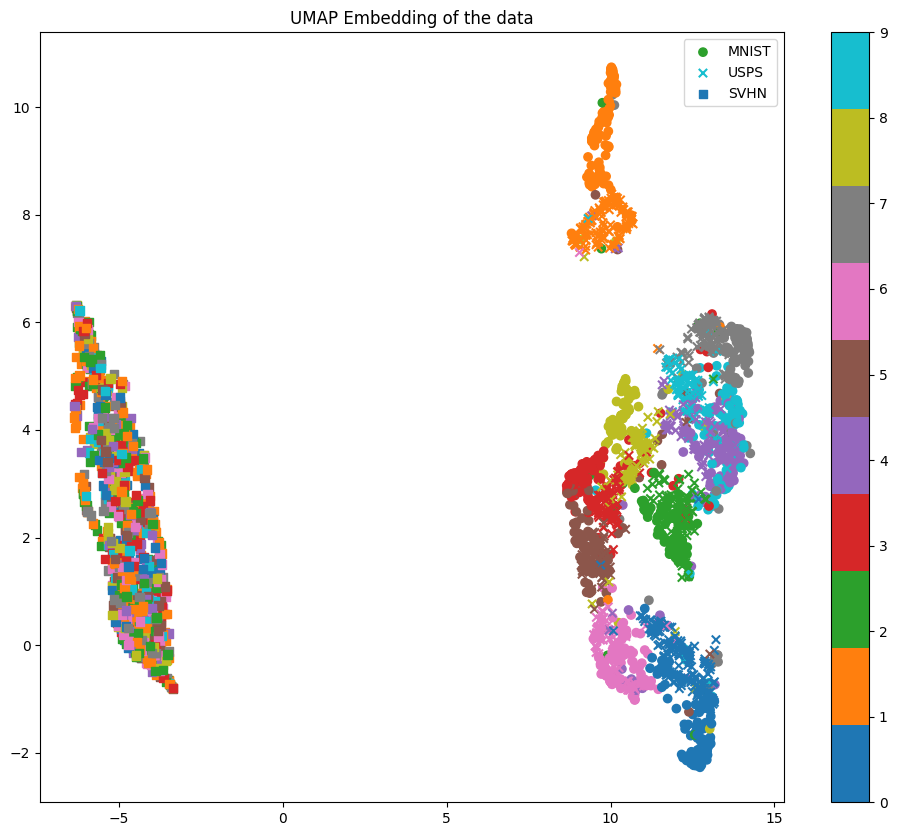

In [21]:
plt.figure(3,(12,10))

plt.scatter(xpMNIST[:,0],xpMNIST[:,1],c=MNIST_ytrain_res,marker='o',cmap='tab10',label='MNIST')
plt.scatter(xpUSPS[:,0],xpUSPS[:,1],c=USPS_ytrain_res,marker='x',cmap='tab10',label='USPS')
plt.scatter(xpSVHN[:,0],xpSVHN[:,1],c=SVHN_ytrain_res,marker='s',cmap='tab10',label='SVHN')
plt.legend()
plt.colorbar()
plt.title('UMAP Embedding of the data')
plt.show()

It seems that one dataset is quite different from the other two.

**Question**: What are your conclusions ? Re-run the code showing only the most similar datasets.



> As anticipated, the SVHN dataset exhibits significant differences from the MNIST and USPS datasets, as demonstrated through the application of UMAP. This distinction is also apparent during the visualization process. We can also see that the SVHN classes are not separable, and the gap between the MNIST and USPS datasets is not significant, except for some classes like 1.


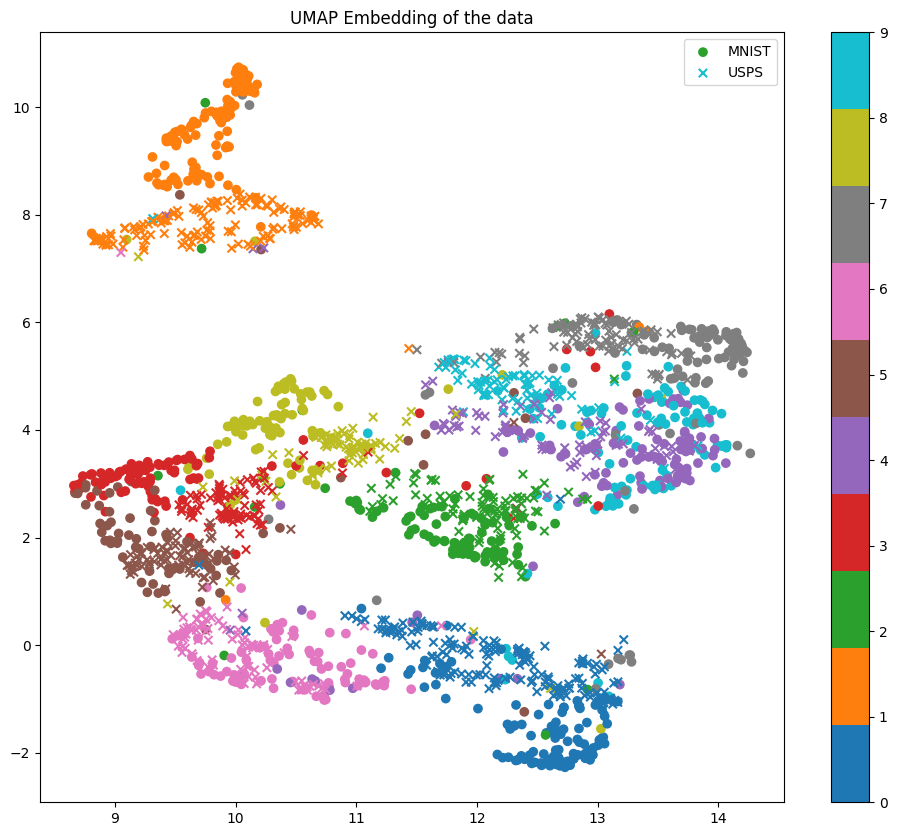

In [22]:
plt.figure(3,(12,10))

plt.scatter(xpMNIST[:,0],xpMNIST[:,1],c=MNIST_ytrain_res,marker='o',cmap='tab10',label='MNIST')
plt.scatter(xpUSPS[:,0],xpUSPS[:,1],c=USPS_ytrain_res,marker='x',cmap='tab10',label='USPS')

plt.legend()
plt.colorbar()
plt.title('UMAP Embedding of the data')
plt.show()

**Question**: Can you see a domain shift between the datasets ?



> While there is some overlap between the two datasets in certain regions, many clusters exhibit clear separation, suggesting differences in the underlying feature distributions of the two datasets.



Now we can test the t-SNE algorithm to check whether your conclusions are confirmed.

In [23]:
%time xp=TSNE().fit_transform(xtot) # this should take around 50 sec

print(xp.shape)

# separate again but now in 2D
xpMNIST=xp[:nMNIST,:]
xpUSPS=xp[nMNIST:nMNIST+nUSPS,:]
xpSVHN=xp[nMNIST+nUSPS:,:]
print(xpMNIST.shape,xpUSPS.shape,xpSVHN.shape)

CPU times: user 25.9 s, sys: 113 ms, total: 26 s
Wall time: 26 s
(3000, 2)
(1000, 2) (1000, 2) (1000, 2)


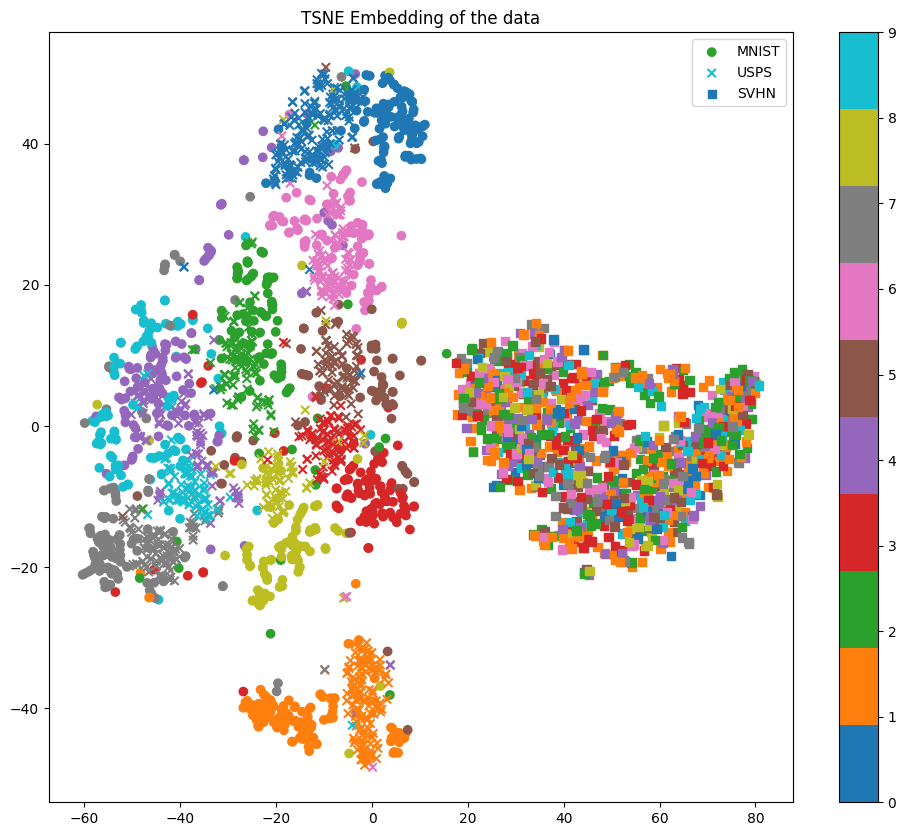

In [24]:
plt.figure(3,(12,10))

plt.scatter(xpMNIST[:,0],xpMNIST[:,1],c=MNIST_ytrain_res,marker='o',cmap='tab10',label='MNIST')
plt.scatter(xpUSPS[:,0],xpUSPS[:,1],c=USPS_ytrain_res,marker='x',cmap='tab10',label='USPS')
plt.scatter(xpSVHN[:,0],xpSVHN[:,1],c=SVHN_ytrain_res,marker='s',cmap='tab10',label='SVHN')
plt.legend()
plt.colorbar()
plt.title('TSNE Embedding of the data')
plt.show()

**Question**: can you confirm your previous conclusions ?



> the t-SNE plot strengthens the observation of domain shifts between the datasets, particularly emphasizing the distinct nature of SVHN compared to MNIST and USPS.



It seems that one dataset is quite different from the other two data-sets.

**Question**: Analyse that dataset alone using UMAP (faster)

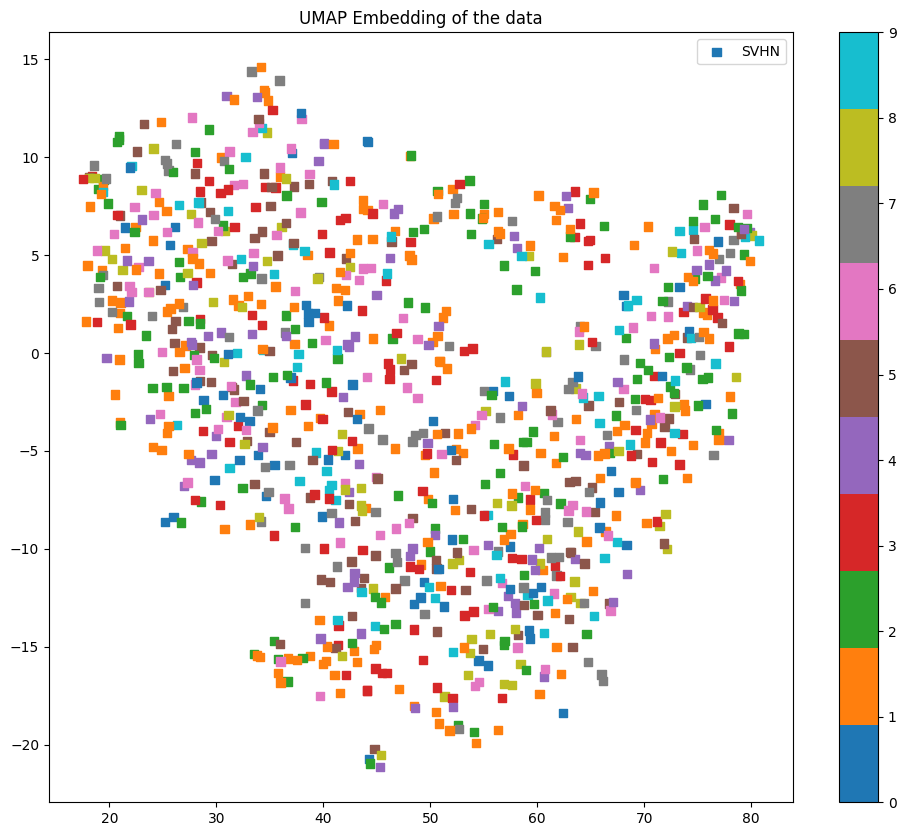

In [25]:

plt.figure(3,(12,10))


plt.scatter(xpSVHN[:,0],xpSVHN[:,1],c=SVHN_ytrain_res,marker='s',cmap='tab10',label='SVHN')
plt.legend()
plt.colorbar()
plt.title('UMAP Embedding of the data')
plt.show()

**Question**: Are the data clearly clustered and well separated as for the other two datasets ? If not, why is that in your opinion ?

Hint: think about the input space of UMAP...



> the Street View House Numbers (SVHN) dataset often contains images with multiple digits in a single image, as it represents natural house numbers captured in real-world scenarios. This introduces significant challenges for clustering or embedding methods like UMAP and t-SNE.


# Unsupervised Domain Adaptation

The three data-sets have the same features $\mathcal{X}$ (all images have size $[32 x 32]$)
 and the same classes (output labels) $\mathcal{Y}$ but they have different marginal $p(X)$ distributions.

In this part, we will assume that we only have labeled data in the source domain $S$ but not int the target domain $T$. By matching the source $p_S(X)$ and target $p_T(X)$ marginal distributions, one can hope that a classifier learnt on $S$ will also work on $T$.

Here, you will implement and test the following algorithm based on subspace alignement:

B. Fernando et al. "*Unsupervised Visual Domain Adaptation Using Subspace Alignment*". ICCV, 2013.

The first thing to do is to choose the source domain and the target domain.
Let's start with the MNIST dataset as source and USPS as target.

We will use the previousyly computed reduced datasets to speed up computations.

## Source: MNIST, Target: USPS

In [36]:
# Source domain
XtrainS = MNIST_Xtrain_res
ytrainS = MNIST_ytrain_res
XtestS = MNIST_Xtest
ytestS = MNIST_ytest

# # Target domain
XtrainT = USPS_Xtrain_res
ytrainT = USPS_ytrain_res
XtestT = USPS_Xtest
ytestT = USPS_ytest

# Target domain
# XtrainT = SVHN_Xtrain_res
# ytrainT = SVHN_ytrain_res
# XtestT = SVHN_Xtest
# ytestT = SVHN_ytest

Ns=1000 # number of samples in source domain
Nt=1000 # number of samples in target domain

*Implement* the method following the description of the method in the slides of the lecture (around slide 75).  

In [37]:

def SA(XTrainS, XTestS, XTrainT, XTestT, d=10):
    """
    Subspace Alignment (SA)

    Input
    XTrainS : Input training source data [NTrS,D]
    XTestS : Input test source data [NTeS,D]
    XTrainT : Input training target data [NTrT,D]
    XTestT : Input test target data [NTeT,D]
    d : number of PCA components

    Output
    XTrainSp : projected and transformed source training data [NTrS,d]
    XTestSp : projected and transformed source test data [NTeS,d]
    XTrainTp : projected training target data [NTrT,d]
    XTestTp : projected test target data [NTeT,d]
    """
    # Perform PCA on source and target data
    pca_source = PCA(n_components=d)
    US = pca_source.fit(XTrainS).components_.T  # Source PCA components

    pca_target = PCA(n_components=d)
    UT = pca_target.fit(XTrainT).components_.T  # Target PCA components

    # Compute transformation matrix M
    M_star = US.T @ UT

    # Project and transform source data
    XTrainSp = XTrainS @ US @ M_star
    XTestSp = XTestS @ US @ M_star

    # Project target data
    XTrainTp = XTrainT @ UT
    XTestTp = XTestT @ UT

    return XTrainSp, XTestSp, XTrainTp, XTestTp

We start by veryfying the score of a classifier trained on the source domain and tested on the target domain (no adaptation).

You can use the classifier you want (e.g., logistic regression, SVM, ...)

In [41]:




# Train an SVM on the source domain (transformed features)
svm_classifier = SVC(kernel='linear', C=1.0, random_state=42)
svm_classifier.fit(XtrainS, ytrainS)

# Test the SVM on the target domain (transformed features)
yPredT = svm_classifier.predict(XtestT)
yPredS = svm_classifier.predict(XtestS)
# Calculate and print accuracy on the target domain
accuracy = accuracy_score(ytestT, yPredT)
accuracy_source = accuracy_score(ytestS, yPredS)
print(f"Accuracy on the source domain : {accuracy_source:.4f}")
print(f"Accuracy on the target domain without adaptation: {accuracy:.4f}")



Accuracy on the source domain : 0.8905
Accuracy on the target domain without adaptation: 0.6208


To reduce dimensionality, we can also first compute PCA using the source training set and then project (i.e., transform) all data (source and target, training and test) on the first $d$ components.

**Question**: try different values of $d$. Is there a difference with the previous full-training data appraoch ?

d = 5: Accuracy on source domain = 0.6920, target domain = 0.3503
d = 10: Accuracy on source domain = 0.8109, target domain = 0.5062
d = 20: Accuracy on source domain = 0.8698, target domain = 0.6168
d = 30: Accuracy on source domain = 0.8714, target domain = 0.6228
d = 40: Accuracy on source domain = 0.8767, target domain = 0.6029
d = 50: Accuracy on source domain = 0.8825, target domain = 0.6129
d = 50: Accuracy on source domain = 0.8808, target domain = 0.6139
d = 70: Accuracy on source domain = 0.8838, target domain = 0.6228
d = 80: Accuracy on source domain = 0.8865, target domain = 0.6213
d = 90: Accuracy on source domain = 0.8867, target domain = 0.6258
d = 100: Accuracy on source domain = 0.8854, target domain = 0.6323
d = 200: Accuracy on source domain = 0.8895, target domain = 0.6298
d = 300: Accuracy on source domain = 0.8899, target domain = 0.6243
d = 500: Accuracy on source domain = 0.8903, target domain = 0.6208
d = 1000: Accuracy on source domain = 0.8905, target domain

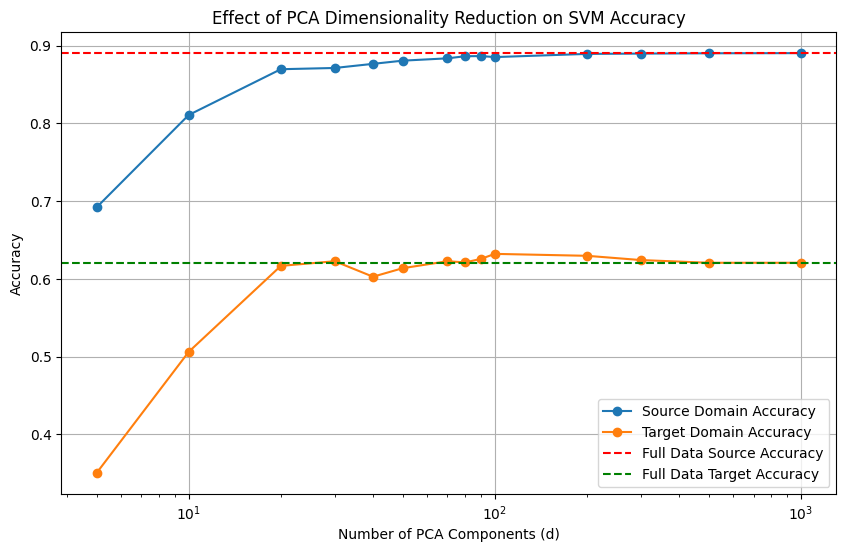

In [46]:



# Define the range of principal components to try
d_values = [5, 10, 20, 30, 40, 50, 50, 70, 80, 90, 100, 200, 300, 500, 1000]

# Store results for analysis
results = []

for d in d_values:
    # Apply PCA to reduce dimensionality
    pca = PCA(n_components=d)
    XtrainS_pca = pca.fit_transform(XtrainS)
    XtestS_pca = pca.transform(XtestS)
    XtrainT_pca = pca.transform(XtrainT)
    XtestT_pca = pca.transform(XtestT)

    # Train SVM on the PCA-transformed source training set
    svm_classifier = SVC(kernel='linear', C=1.0, random_state=42)
    svm_classifier.fit(XtrainS_pca, ytrainS)

    # Test the SVM on both source and target domains
    yPredS = svm_classifier.predict(XtestS_pca)
    yPredT = svm_classifier.predict(XtestT_pca)

    # Calculate accuracies
    accuracy_source = accuracy_score(ytestS, yPredS)
    accuracy_target = accuracy_score(ytestT, yPredT)

    # Store results
    results.append((d, accuracy_source, accuracy_target))
    print(f"d = {d}: Accuracy on source domain = {accuracy_source:.4f}, target domain = {accuracy_target:.4f}")

# Compare results with full-dimensional data
print("\nResults with full-dimensional data:")
svm_classifier_full = SVC(kernel='linear', C=1.0, random_state=42)
svm_classifier_full.fit(XtrainS, ytrainS)
accuracy_source_full = accuracy_score(ytestS, svm_classifier_full.predict(XtestS))
accuracy_target_full = accuracy_score(ytestT, svm_classifier_full.predict(XtestT))
print(f"Full data: Accuracy on source domain = {accuracy_source_full:.4f}, target domain = {accuracy_target_full:.4f}")

# Analyze results
print("\nComparison of PCA-reduced and full-dimensional accuracies:")
for d, acc_source, acc_target in results:
    print(f"d = {d}: Source = {acc_source:.4f}, Target = {acc_target:.4f}")

# Remove duplicates and ensure data alignment
unique_results = {}
for d, acc_source, acc_target in results:
    unique_results[d] = (acc_source, acc_target)  # Overwrite duplicate entries

d_values_unique = list(unique_results.keys())
source_accuracies = [unique_results[d][0] for d in d_values_unique]
target_accuracies = [unique_results[d][1] for d in d_values_unique]

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(d_values_unique, source_accuracies, label="Source Domain Accuracy", marker='o')
plt.plot(d_values_unique, target_accuracies, label="Target Domain Accuracy", marker='o')

# Highlight full-dimensional data accuracy
plt.axhline(y=accuracy_source_full, color='r', linestyle='--', label="Full Data Source Accuracy")
plt.axhline(y=accuracy_target_full, color='g', linestyle='--', label="Full Data Target Accuracy")

# Add labels, title, and legend
plt.xscale('log')
plt.xlabel("Number of PCA Components (d)")
plt.ylabel("Accuracy")
plt.title("Effect of PCA Dimensionality Reduction on SVM Accuracy")
plt.legend()
plt.grid(True)
plt.show()




> For large values of \( d \), the performance converges to the baseline, underscoring the diminishing returns associated with high-dimensional representations in this context. The full-dimensional data approach continues to demonstrate superior performance. Nonetheless, if computational efficiency is prioritized, PCA-based dimensionality reduction offer a favorable trade-off, particularly when higher values of \( d \) are employed.


We can now test the SA approach.

**Question**: try different values of $d$. Does the performance improve on the target domain ? Try at least two different ML methods (one linear and one non-linear) and one DL architecture (it can be a pre-trained model or a simple architecture). What's the best ?

Accuracy on the target domain with SVM (d=5): 0.1614
Accuracy on the target domain with MLP (d=5): 0.1295
Accuracy on the target domain with Random Forest (d=5): 0.3000
Accuracy on the target domain with SVM (d=10): 0.5904
Accuracy on the target domain with MLP (d=10): 0.4928
Accuracy on the target domain with Random Forest (d=10): 0.5571
Accuracy on the target domain with SVM (d=20): 0.6398
Accuracy on the target domain with MLP (d=20): 0.7270
Accuracy on the target domain with Random Forest (d=20): 0.6203
Accuracy on the target domain with SVM (d=30): 0.6881
Accuracy on the target domain with MLP (d=30): 0.6716
Accuracy on the target domain with Random Forest (d=30): 0.6089
Accuracy on the target domain with SVM (d=40): 0.7195
Accuracy on the target domain with MLP (d=40): 0.6816
Accuracy on the target domain with Random Forest (d=40): 0.6139
Accuracy on the target domain with SVM (d=50): 0.7329
Accuracy on the target domain with MLP (d=50): 0.7025
Accuracy on the target domain with 

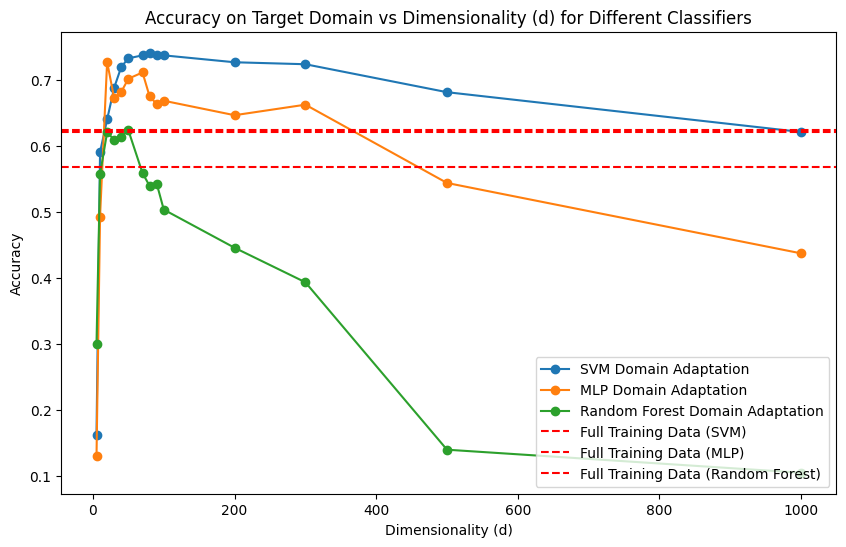

In [55]:
# List of different values for d to test
d_values = [5, 10, 20, 30, 40, 50, 50, 70, 80, 90, 100, 200, 300, 500, 1000]


# Initialize dictionaries to store results
accuracy_results = {
    'SVM': {},
    'MLP': {},
    'Random Forest': {}
}

# Define classifiers
classifiers = {
    'SVM': SVC(kernel='linear', C=1.0, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Loop over different values of d
for d in d_values:
    # Perform domain adaptation with the current value of d
    XTrainSp, XTestSp, XTrainTp, XTestTp = SA(XtrainS, XtestS, XtrainT, XtestT, d=d)

    # Loop over each classifier
    for clf_name, clf in classifiers.items():
        # Train the classifier on the source domain (transformed features)
        clf.fit(XTrainSp, ytrainS)

        # Test the classifier on the target domain (transformed features)
        yPredT = clf.predict(XTestTp)

        # Calculate and store accuracy on the target domain
        accuracy = accuracy_score(ytestT, yPredT)
        accuracy_results[clf_name][d] = accuracy
        print(f"Accuracy on the target domain with {clf_name} (d={d}): {accuracy:.4f}")

# Compare with the full training data approach (no domain adaptation)
for clf_name, clf in classifiers.items():
    clf.fit(XtrainS, ytrainS)  # Train on the full source domain data
    yPredT_full = clf.predict(XtestT)  # Test on the target domain
    accuracy_full = accuracy_score(ytestT, yPredT_full)
    print(f"Accuracy on the target domain with full training data ({clf_name}): {accuracy_full:.4f}")

# Plot accuracy for different values of d
plt.figure(figsize=(10, 6))

# Plot for each classifier
for clf_name in classifiers.keys():
    plt.plot(list(accuracy_results[clf_name].keys()), list(accuracy_results[clf_name].values()), marker='o', label=f'{clf_name} Domain Adaptation')

# Add horizontal lines for the full training data case
for clf_name in classifiers.keys():
    accuracy_full = accuracy_score(ytestT, classifiers[clf_name].predict(XtestT))
    plt.axhline(y=accuracy_full, color='r', linestyle='--', label=f'Full Training Data ({clf_name})')

# Add labels, title, and legend
plt.xlabel('Dimensionality (d)')
plt.ylabel('Accuracy')
plt.title('Accuracy on Target Domain vs Dimensionality (d) for Different Classifiers')
plt.legend()

# Show the plot
plt.show()




> MLP with d=20 stands out as the best model in terms of achieving a good balance between a relatively small dimension and high accuracy. It achieves an accuracy of 0.7270, which is quite strong compared to other models at smaller dimensions. The MLP model at d=20 provides a good trade-off by maintaining a reasonably low dimensionality while delivering a high accuracy on the target domain, making it the optimal choice in this case.



**Question**: Use the UMAP or t-SNE visualization to check whether the data are more similar after the SA adaptation. What can you conclude ?

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


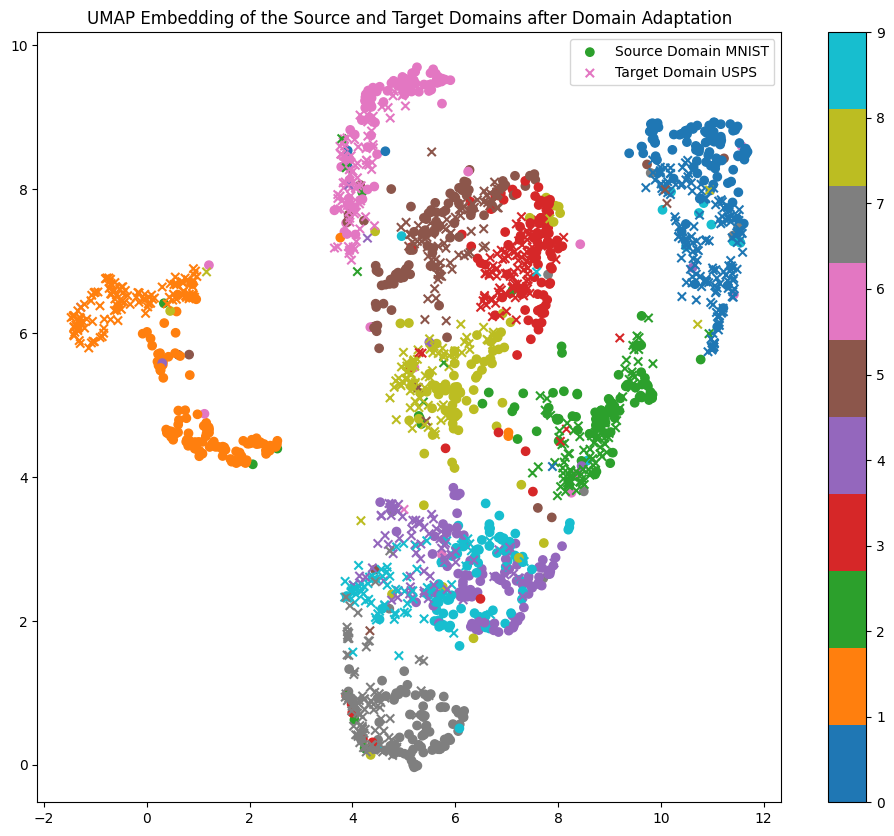

In [38]:


# Perform domain adaptation with a specific value of d
XTrainSp, XTestSp, XTrainTp, XTestTp = SA(XtrainS, XtestS, XtrainT, XtestT, d=80)  # Example with d=30

# Combine the source and target domain data after adaptation
xtot = np.concatenate([XTrainSp, XTrainTp], axis=0)

# Apply UMAP to reduce the dimensionality to 2D
xp = UMAP().fit_transform(xtot)

# Separate the transformed data back into source and target domain
xpSource = xp[:XTrainSp.shape[0], :]
xpTarget = xp[XTrainSp.shape[0]:, :]

# Plot the UMAP embedding of the source and target domains
plt.figure(figsize=(12, 10))
plt.scatter(xpSource[:, 0], xpSource[:, 1], c=ytrainS, marker='o', cmap='tab10', label='Source Domain MNIST')
plt.scatter(xpTarget[:, 0], xpTarget[:, 1], c=ytrainT, marker='x', cmap='tab10', label='Target Domain USPS')
plt.legend()
plt.colorbar()
plt.title('UMAP Embedding of the Source and Target Domains after Domain Adaptation')
plt.show()




> The modification is barely noticeable between the before SA and the after.



## Source MNIST, Target: SVHN

In [72]:
# Source domain
XtrainS = MNIST_Xtrain_res
ytrainS = MNIST_ytrain_res
XtestS = MNIST_Xtest
ytestS = MNIST_ytest

# # Target domain
# XtrainT = USPS_Xtrain_res
# ytrainT = USPS_ytrain_res
# XtestT = USPS_Xtest
# ytestT = USPS_ytest

# Target domain
XtrainT = SVHN_Xtrain_res
ytrainT = SVHN_ytrain_res
XtestT = SVHN_Xtest
ytestT = SVHN_ytest

Ns=1000 # number of samples in source domain
Nt=1000 # number of samples in target domain

d = 5: Accuracy on source domain = 0.6921, target domain = 0.0820
d = 10: Accuracy on source domain = 0.8113, target domain = 0.1091
d = 20: Accuracy on source domain = 0.8688, target domain = 0.1221
d = 30: Accuracy on source domain = 0.8707, target domain = 0.1203
d = 40: Accuracy on source domain = 0.8767, target domain = 0.1262
d = 50: Accuracy on source domain = 0.8808, target domain = 0.1392
d = 50: Accuracy on source domain = 0.8811, target domain = 0.1395
d = 70: Accuracy on source domain = 0.8836, target domain = 0.1603
d = 80: Accuracy on source domain = 0.8849, target domain = 0.1613
d = 90: Accuracy on source domain = 0.8867, target domain = 0.1637
d = 100: Accuracy on source domain = 0.8862, target domain = 0.1597
d = 200: Accuracy on source domain = 0.8886, target domain = 0.1648
d = 300: Accuracy on source domain = 0.8893, target domain = 0.1659
d = 500: Accuracy on source domain = 0.8903, target domain = 0.1653
d = 1000: Accuracy on source domain = 0.8905, target domain

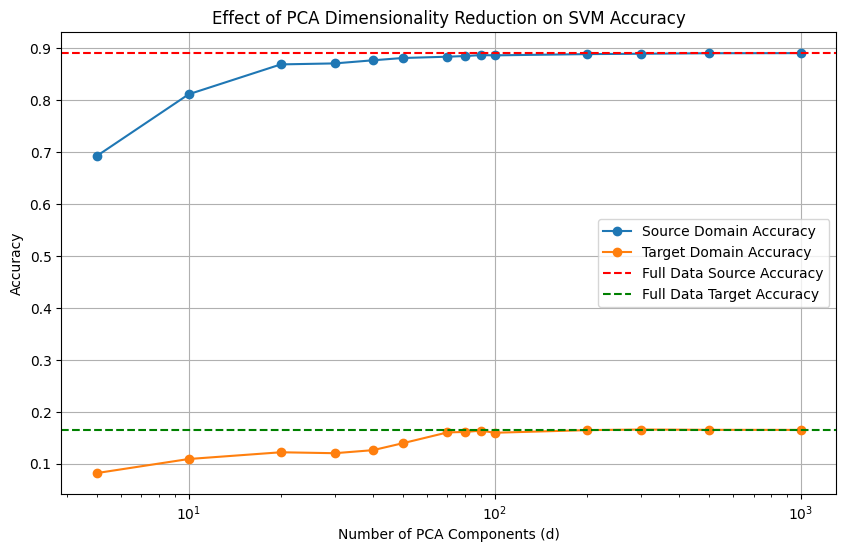

In [66]:


# Define the range of principal components to try
d_values = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 500, 1000]

# Store results for analysis
results = []

for d in d_values:
    # Apply PCA to reduce dimensionality
    pca = PCA(n_components=d)
    XtrainS_pca = pca.fit_transform(XtrainS)
    XtestS_pca = pca.transform(XtestS)
    XtrainT_pca = pca.transform(XtrainT)
    XtestT_pca = pca.transform(XtestT)

    # Train SVM on the PCA-transformed source training set
    svm_classifier = SVC(kernel='linear', C=1.0, random_state=42)
    svm_classifier.fit(XtrainS_pca, ytrainS)

    # Test the SVM on both source and target domains
    yPredS = svm_classifier.predict(XtestS_pca)
    yPredT = svm_classifier.predict(XtestT_pca)

    # Calculate accuracies
    accuracy_source = accuracy_score(ytestS, yPredS)
    accuracy_target = accuracy_score(ytestT, yPredT)

    # Store results
    results.append((d, accuracy_source, accuracy_target))
    print(f"d = {d}: Accuracy on source domain = {accuracy_source:.4f}, target domain = {accuracy_target:.4f}")

# Compare results with full-dimensional data
print("\nResults with full-dimensional data:")
svm_classifier_full = SVC(kernel='linear', C=1.0, random_state=42)
svm_classifier_full.fit(XtrainS, ytrainS)
accuracy_source_full = accuracy_score(ytestS, svm_classifier_full.predict(XtestS))
accuracy_target_full = accuracy_score(ytestT, svm_classifier_full.predict(XtestT))
print(f"Full data: Accuracy on source domain = {accuracy_source_full:.4f}, target domain = {accuracy_target_full:.4f}")

# Analyze results
print("\nComparison of PCA-reduced and full-dimensional accuracies:")
for d, acc_source, acc_target in results:
    print(f"d = {d}: Source = {acc_source:.4f}, Target = {acc_target:.4f}")

# Remove duplicates and ensure data alignment
unique_results = {}
for d, acc_source, acc_target in results:
    unique_results[d] = (acc_source, acc_target)  # Overwrite duplicate entries

d_values_unique = list(unique_results.keys())
source_accuracies = [unique_results[d][0] for d in d_values_unique]
target_accuracies = [unique_results[d][1] for d in d_values_unique]

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(d_values_unique, source_accuracies, label="Source Domain Accuracy", marker='o')
plt.plot(d_values_unique, target_accuracies, label="Target Domain Accuracy", marker='o')

# Highlight full-dimensional data accuracy
plt.axhline(y=accuracy_source_full, color='r', linestyle='--', label="Full Data Source Accuracy")
plt.axhline(y=accuracy_target_full, color='g', linestyle='--', label="Full Data Target Accuracy")

# Add labels, title, and legend
plt.xscale('log')
plt.xlabel("Number of PCA Components (d)")
plt.ylabel("Accuracy")
plt.title("Effect of PCA Dimensionality Reduction on SVM Accuracy")
plt.legend()
plt.grid(True)
plt.show()


Accuracy on the target domain with SVM (d=5): 0.0763
Accuracy on the target domain with MLP (d=5): 0.1107
Accuracy on the target domain with Random Forest (d=5): 0.1196
Accuracy on the target domain with SVM (d=10): 0.1830
Accuracy on the target domain with MLP (d=10): 0.1363
Accuracy on the target domain with Random Forest (d=10): 0.1533
Accuracy on the target domain with SVM (d=20): 0.1741
Accuracy on the target domain with MLP (d=20): 0.1618
Accuracy on the target domain with Random Forest (d=20): 0.1484
Accuracy on the target domain with SVM (d=30): 0.1585
Accuracy on the target domain with MLP (d=30): 0.1076
Accuracy on the target domain with Random Forest (d=30): 0.1620
Accuracy on the target domain with SVM (d=40): 0.1338
Accuracy on the target domain with MLP (d=40): 0.1597
Accuracy on the target domain with Random Forest (d=40): 0.1597
Accuracy on the target domain with SVM (d=50): 0.1516
Accuracy on the target domain with MLP (d=50): 0.1652
Accuracy on the target domain with 

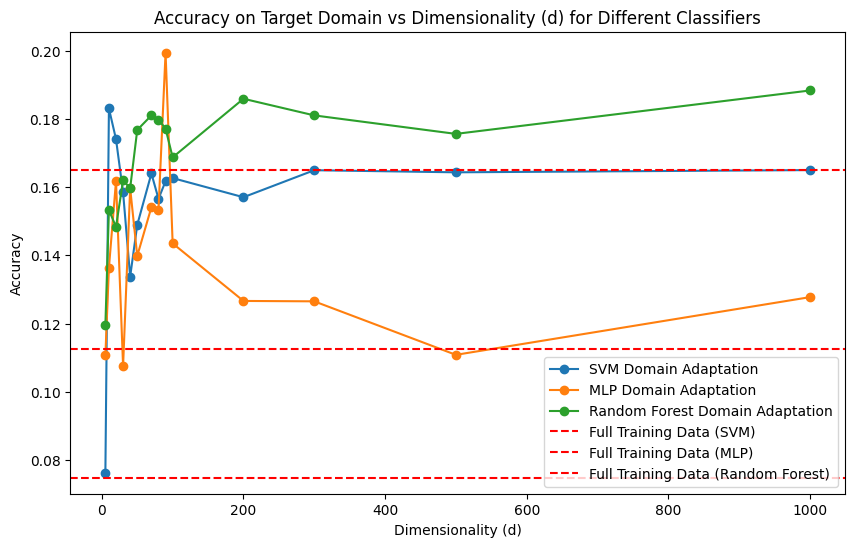

In [67]:
# List of different values for d to test
d_values = [5, 10, 20, 30, 40, 50, 50, 70, 80, 90, 100, 200, 300, 500, 1000]

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Initialize dictionaries to store results
accuracy_results = {
    'SVM': {},
    'MLP': {},
    'Random Forest': {}
}

# Define classifiers
classifiers = {
    'SVM': SVC(kernel='linear', C=1.0, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Loop over different values of d
for d in d_values:
    # Perform domain adaptation with the current value of d
    XTrainSp, XTestSp, XTrainTp, XTestTp = SA(XtrainS, XtestS, XtrainT, XtestT, d=d)

    # Loop over each classifier
    for clf_name, clf in classifiers.items():
        # Train the classifier on the source domain (transformed features)
        clf.fit(XTrainSp, ytrainS)

        # Test the classifier on the target domain (transformed features)
        yPredT = clf.predict(XTestTp)

        # Calculate and store accuracy on the target domain
        accuracy = accuracy_score(ytestT, yPredT)
        accuracy_results[clf_name][d] = accuracy
        print(f"Accuracy on the target domain with {clf_name} (d={d}): {accuracy:.4f}")

# Compare with the full training data approach (no domain adaptation)
for clf_name, clf in classifiers.items():
    clf.fit(XtrainS, ytrainS)  # Train on the full source domain data
    yPredT_full = clf.predict(XtestT)  # Test on the target domain
    accuracy_full = accuracy_score(ytestT, yPredT_full)
    print(f"Accuracy on the target domain with full training data ({clf_name}): {accuracy_full:.4f}")

# Plot accuracy for different values of d
plt.figure(figsize=(10, 6))

# Plot for each classifier
for clf_name in classifiers.keys():
    plt.plot(list(accuracy_results[clf_name].keys()), list(accuracy_results[clf_name].values()), marker='o', label=f'{clf_name} Domain Adaptation')

# Add horizontal lines for the full training data case
for clf_name in classifiers.keys():
    accuracy_full = accuracy_score(ytestT, classifiers[clf_name].predict(XtestT))
    plt.axhline(y=accuracy_full, color='r', linestyle='--', label=f'Full Training Data ({clf_name})')

# Add labels, title, and legend
plt.xlabel('Dimensionality (d)')
plt.ylabel('Accuracy')
plt.title('Accuracy on Target Domain vs Dimensionality (d) for Different Classifiers')
plt.legend()

# Show the plot
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


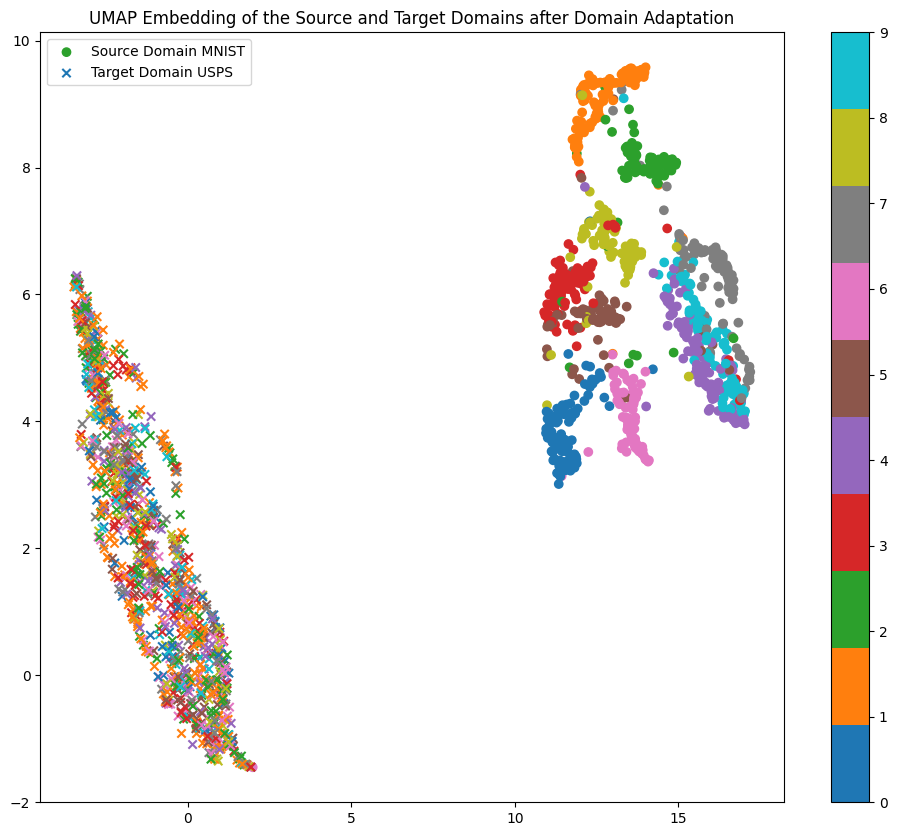

In [78]:


# Perform domain adaptation with a specific value of d
XTrainSp, XTestSp, XTrainTp, XTestTp = SA(XtrainS, XtestS, XtrainT, XtestT, d=200)  # Example with d=30

# Combine the source and target domain data after adaptation
xtot = np.concatenate([XTrainSp, XTrainTp], axis=0)

# Apply UMAP to reduce the dimensionality to 2D
xp = UMAP().fit_transform(xtot)

# Separate the transformed data back into source and target domain
xpSource = xp[:XTrainSp.shape[0], :]
xpTarget = xp[XTrainSp.shape[0]:, :]

# Plot the UMAP embedding of the source and target domains
plt.figure(figsize=(12, 10))
plt.scatter(xpSource[:, 0], xpSource[:, 1], c=ytrainS, marker='o', cmap='tab10', label='Source Domain MNIST')
plt.scatter(xpTarget[:, 0], xpTarget[:, 1], c=ytrainT, marker='x', cmap='tab10', label='Target Domain USPS')
plt.legend()
plt.colorbar()
plt.title('UMAP Embedding of the Source and Target Domains after Domain Adaptation')
plt.show()


**Question**: Repeat the same experiments for different Source and Target domains. Use at least the two followng configurations:

Source: MNIST, Target: USPS

Source MNIST, Target: SVHN

**Queston**: Comment the results



> We can conclude that the model that outperformed others in this context was the Multi-Layer Perceptron (MLP), as the data is difficult to distinguish (see figure below) after the application of Subspace Analysis (SA), it requires additional dimensions to achieve better performance compared to the previous case. This is primarily attributable to the significant shift between the domains.




> It remains challenging to achieve optimal performance on the SVHN dataset. Although some improvements have been observed, the overall performance is still unsatisfactory. Additionally, I did not conduct an in-depth exploration of hyperparameter tuning.


**Question**: What does it happen if you decrease the number of samples for the labeled training set? Is it expected based on the theory seen during the lecture ?



> Decreasing the number of samples in the labeled training set can lead to reduced model performance, increased overfitting, higher variance in results,



**Optional**: You can test other methods using the `adapt`library. See `https://adapt-python.github.io/adapt/`. You will need Tensorflow==2.15

Here, you can test the MDD and DANN methods using a very simple architecture for both the encoder and discriminator.

In [80]:
pip install adapt

INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 109.5 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.2.0
    Uninstalling ml-dtypes-0.2.0:
      Successfully uninstalled ml-dtypes-0.2.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.15.2
    Uninstalling tensorboard-2.15.2:
      Successfully uninstalled tensorboard-2.15.2
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
  Attempting uninstall: tensorflow
    Found existi

In [86]:
!pip install tensorflow==2.17.0 keras==2.17.0 #Installing compatible versions

ERROR: Could not find a version that satisfies the requirement keras==2.17.0 (from versions: 0.2.0, 0.3.0, 0.3.1, 0.3.2, 0.3.3, 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.0.4, 1.0.5, 1.0.6, 1.0.7, 1.0.8, 1.1.0, 1.1.1, 1.1.2, 1.2.0, 1.2.1, 1.2.2, 2.0.0, 2.0.1, 2.0.2, 2.0.3, 2.0.4, 2.0.5, 2.0.6, 2.0.7, 2.0.8, 2.0.9, 2.1.0, 2.1.1, 2.1.2, 2.1.3, 2.1.4, 2.1.5, 2.1.6, 2.2.0, 2.2.1, 2.2.2, 2.2.3, 2.2.4, 2.2.5, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.4.2, 2.4.3, 2.5.0rc0, 2.6.0rc0, 2.6.0rc1, 2.6.0rc2, 2.6.0rc3, 2.6.0, 2.7.0rc0, 2.7.0rc2, 2.7.0, 2.8.0rc0, 2.8.0rc1, 2.8.0, 2.9.0rc0, 2.9.0rc1, 2.9.0rc2, 2.9.0, 2.10.0rc0, 2.10.0rc1, 2.10.0, 2.11.0rc0, 2.11.0rc1, 2.11.0rc2, 2.11.0rc3, 2.11.0, 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.13.1rc0, 2.13.1rc1, 2.13.1, 2.14.0rc0, 2.14.0, 2.15.0rc0, 2.15.0rc1, 2.15.0, 3.0.0, 3.0.1, 3.0.2, 3.0.3, 3.0.4, 3.0.5, 3.1.0, 3.1.1, 3.2.0, 3.2.1, 3.3.0, 3.3.1, 3.3.2, 3.3.3, 3.4.0, 3.4.1, 3.5.0, 3.6.0, 3.7.0, 3.8.0)
ERROR: No matching distribution found for keras==2.17.0


In [87]:
!pip install numpy scipy tensorflow scikit-learn cvxopt


In [1]:
!pip install adapt

In [ ]:
import os
os.kill(os.getpid(), 9)


In [31]:
from adapt.feature_based import MDD
model = MDD(lambda_=0.1, gamma=4., Xt=XtrainT, metrics=["accuracy"], random_state=0)

model.fit(XtrainS, ytrainS, epochs=100, verbose=0)
model.score(XtrainS, ytrainS)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'mdd_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


AttributeError: 'MDD' object has no attribute '_is_compiled'

In [ ]:
from adapt.feature_based import DANN

model = DANN(XXXXXX)
model.fit(XXXXXX)
model.score(XXXXXXX)


**Question (Optional)**: try to use a more complex architecture (for instance a pre-trained model) for both the encoder and discriminator. Be careful, the adapt library is written in TensorFlow...